In [1]:
import catboost
from sklearn.metrics import classification_report
import datasets
import numpy as np
import pandas as pd

In [2]:
ds = datasets.load_dataset("iitolstykh/LLMTrace_classification")

README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/1.40G [00:00<?, ?B/s]

valid.jsonl:   0%|          | 0.00/292M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/318M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/411440 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/86696 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/90950 [00:00<?, ? examples/s]

In [3]:
X_train = np.load('/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_train.npy') 
y_train = np.array([0 if label=='ai' else 1 for label in ds['train']['label']])
X_train.shape, y_train.shape

((411440, 768), (411440,))

In [4]:
# list(range(X_train.shape[1]))
# pd.DataFrame(X_train)
# [X_train]
# list(X_train)

In [5]:
len(X_train)

411440

In [6]:
# type(X_train), X_train.shape

In [7]:
train_pool = catboost.Pool(
    data=X_train, 
    label=y_train,
    # embedding_features=[0],
    # embedding_features_data=[X_train]
)

In [9]:
X_valid = np.load('/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_valid.npy')
y_valid = np.array([0 if label=='ai' else 1 for label in ds['validation']['label']])
valid_pool = catboost.Pool(
    data=X_valid,
    label=y_valid,
    # embedding_features=[0],
    # embedding_features_data=[X_valid]
)

In [108]:
model = catboost.CatBoostClassifier(
    iterations=10000,
    learning_rate=0.05,
    depth=6,
    border_count=254,
    l2_leaf_reg=30,
    grow_policy='SymmetricTree',
    task_type='GPU',
    verbose=50,
    custom_metric=['Accuracy', 'Precision', 'Recall', 'F1'],
    eval_metric='TotalF1',
    loss_function='Logloss',
    early_stopping_rounds=50,
    devices='0:1',
    gpu_ram_part=0.9,
    subsample=0.8,
    bootstrap_type='Poisson',
    bagging_temperature=1,
    random_strength=30,
)

In [109]:
model.fit(
    train_pool,
    eval_set=valid_pool,
         )

0:	learn: 0.6292785	test: 0.6297915	best: 0.6297915 (0)	total: 74.2ms	remaining: 12m 22s
50:	learn: 0.7016146	test: 0.6989471	best: 0.6989471 (50)	total: 2.36s	remaining: 7m 40s
100:	learn: 0.7414621	test: 0.7363928	best: 0.7363928 (100)	total: 4.53s	remaining: 7m 24s
150:	learn: 0.7619934	test: 0.7561316	best: 0.7561316 (150)	total: 6.69s	remaining: 7m 16s
200:	learn: 0.7759683	test: 0.7694327	best: 0.7695268 (198)	total: 8.86s	remaining: 7m 12s
250:	learn: 0.7855309	test: 0.7789236	best: 0.7789236 (250)	total: 11s	remaining: 7m 8s
300:	learn: 0.7934903	test: 0.7869548	best: 0.7869548 (300)	total: 13.2s	remaining: 7m 5s
350:	learn: 0.8003325	test: 0.7928760	best: 0.7929096 (349)	total: 15.4s	remaining: 7m 2s
400:	learn: 0.8063293	test: 0.7982245	best: 0.7982245 (400)	total: 17.6s	remaining: 7m
450:	learn: 0.8113816	test: 0.8028749	best: 0.8028749 (450)	total: 19.7s	remaining: 6m 57s
500:	learn: 0.8160808	test: 0.8063416	best: 0.8063416 (500)	total: 21.9s	remaining: 6m 54s
550:	learn: 

CatBoostClassifier(bagging_temperature=1, bootstrap_type='Poisson', border_count=254, custom_metric=['Accuracy', 'Precision', 'Recall', 'F1'], depth=6, devices='0:1', early_stopping_rounds=50, eval_metric='TotalF1', gpu_ram_part=0.9, grow_policy='SymmetricTree', iterations=10000, l2_leaf_reg=30, learning_rate=0.05, loss_function='Logloss', random_strength=30, subsample=0.8, task_type='GPU', verbose=50)

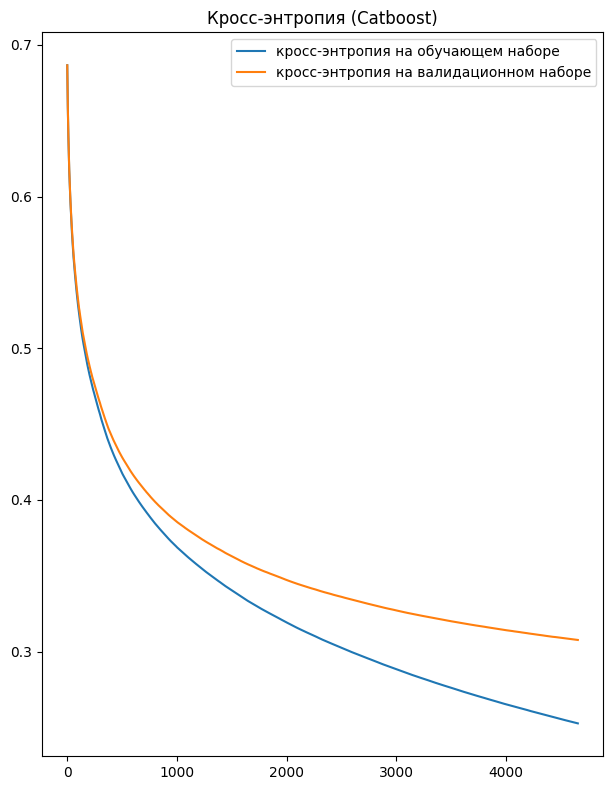


LogLoss (train): 0.252729514023916
LogLoss (vaidation): 0.3077210886315401
Accuracy (train): 0.9085723313241298
Accuracy (vaidation): 0.8714358217218787
Precision (train): 0.8860417171962164
Precision (vaidation): 0.8396359959555106
Recall (train): 0.8858859405028221
Recall (vaidation): 0.8388715818622361
F1 (train): 0.8859638220020675
F1 (vaidation): 0.8391862646082816



In [110]:
import matplotlib.pyplot as plt

results = model.get_evals_result()
best_score = model.get_best_score()
# print(best_score)
learn_loss = results['learn']['Logloss']
valid_loss = results['validation']['Logloss']

test_accuracy = results['validation']['Accuracy']
# print(results['learn'].keys())

plt.figure(figsize=(12,8))
plt.subplot(1, 2, 1)
plt.plot(learn_loss, label='кросс-энтропия на обучающем наборе')
plt.plot(valid_loss, label='кросс-энтропия на валидационном наборе')
plt.title('Кросс-энтропия (Catboost)')
plt.legend()
plt.savefig('LogLoss-catboost.png')
plt.tight_layout()
plt.show()

# plt.plot([0, 0], [10, 10])
print(f"""
LogLoss (train): {best_score['learn']['Logloss']}
LogLoss (vaidation): {best_score['validation']['Logloss']}
Accuracy (train): {best_score['learn']['Accuracy']}
Accuracy (vaidation): {best_score['validation']['Accuracy']}
Precision (train): {best_score['learn']['Precision']}
Precision (vaidation): {best_score['validation']['Precision']}
Recall (train): {best_score['learn']['Recall']}
Recall (vaidation): {best_score['validation']['Recall']}
F1 (train): {best_score['learn']['F1']}
F1 (vaidation): {best_score['validation']['F1']}
""")

In [111]:
X_test = np.load('/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_test.npy')
y_test = np.array([0 if label=='ai' else 1 for label in ds['test']['label']])

test_pool = catboost.Pool(
    data=X_test,
    label=y_test,
)

In [112]:
y_pred = model.predict(test_pool)

In [113]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89     54484
           1       0.84      0.84      0.84     36466

    accuracy                           0.87     90950
   macro avg       0.86      0.86      0.86     90950
weighted avg       0.87      0.87      0.87     90950



In [114]:
y_pred_proba = model.predict_proba(test_pool)

In [119]:
y_pred_proba

array([[0.99475412, 0.00524588],
       [0.63438578, 0.36561422],
       [0.00601034, 0.99398966],
       ...,
       [0.97285227, 0.02714773],
       [0.03420247, 0.96579753],
       [0.0801506 , 0.9198494 ]])

In [123]:
y_test

array([0, 1, 1, ..., 0, 1, 1])

/tmp/ipykernel_55/1249509601.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


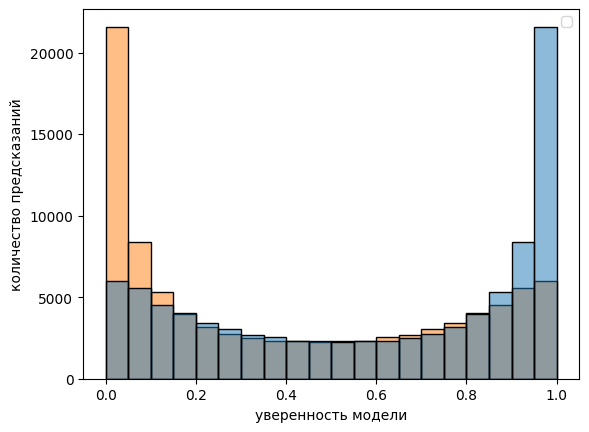

In [129]:
import seaborn as sns

sns.histplot(y_pred_proba, bins=20)
plt.xlabel('уверенность модели')
plt.ylabel('количество предсказаний')

plt.legend()

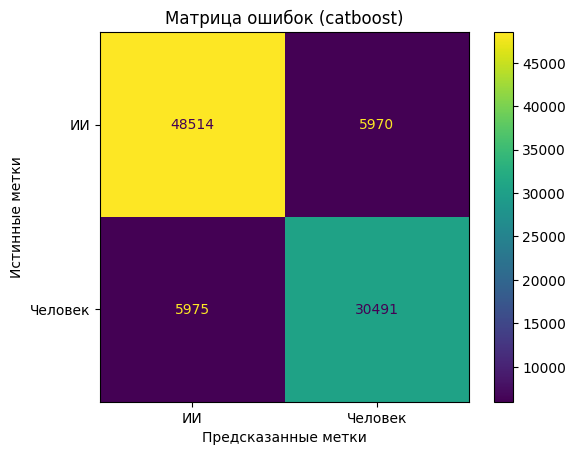

In [148]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf = confusion_matrix(y_true=y_test, y_pred=y_pred)
disp = ConfusionMatrixDisplay(conf)
disp.plot(values_format ='d')
plt.title('Матрица ошибок (catboost)')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.xticks([0,1], ['ИИ', 'Человек'])
plt.yticks([0,1], ['ИИ', 'Человек'])

plt.show()